# Dispersion Bias, Part (ii) — heavy-tailed, simplified (ex-2)

Same decomposition study as `ex-1`, stripped to essentials: one `DesignSpec` + one call to
`fl_graphics.nine_panel_decomposition(model, design)` per sweep. Each figure shows the
Eq. (17) split per factor — **sin²** (out-of-subspace + in-subspace stack, measured line) /
**gap** (paired measured − theory) / **out-of-subspace share** — with 95% CI bands and gridlines.
Returns are **heavy-tailed** (student-t).

In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()  # keep the notebook quiet

from IPython.display import Image, display
from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_theorem_partii import DispersionBiasExperiment
from fl_graphics import nine_panel_decomposition  # pure plotter; renders to PNG (Agg)

OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)

def show(design, name, *, suptitle=None, progress=True):
    """Run the experiment for `design` (tqdm bar over replicates), then plot + display the
    9-panel decomposition. The plotter only consumes the result frame -- it runs nothing."""
    df = run_experiment(model, design, DispersionBiasExperiment(), progress=progress)
    path = OUT_DIR / f"ex2_{name}.png"
    nine_panel_decomposition(df, suptitle=suptitle, out_path=str(path))
    display(Image(filename=str(path)))

# Canonical diagonal-Gram model (factor 1 market-like, c = [2, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 1.0},   # market-like factor (c_1 = 2)
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)

# Heavy tails: student-t factor & idiosyncratic returns, shared by every sweep below.
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 100, 20260511   # bump N_REPS to 1000 for publication-quality CIs
print("ready")

ready


## Growing $p$ (fixed $n = 63$)

The theorem becomes exact as $p\to\infty$ — watch the **gap** row collapse to zero.

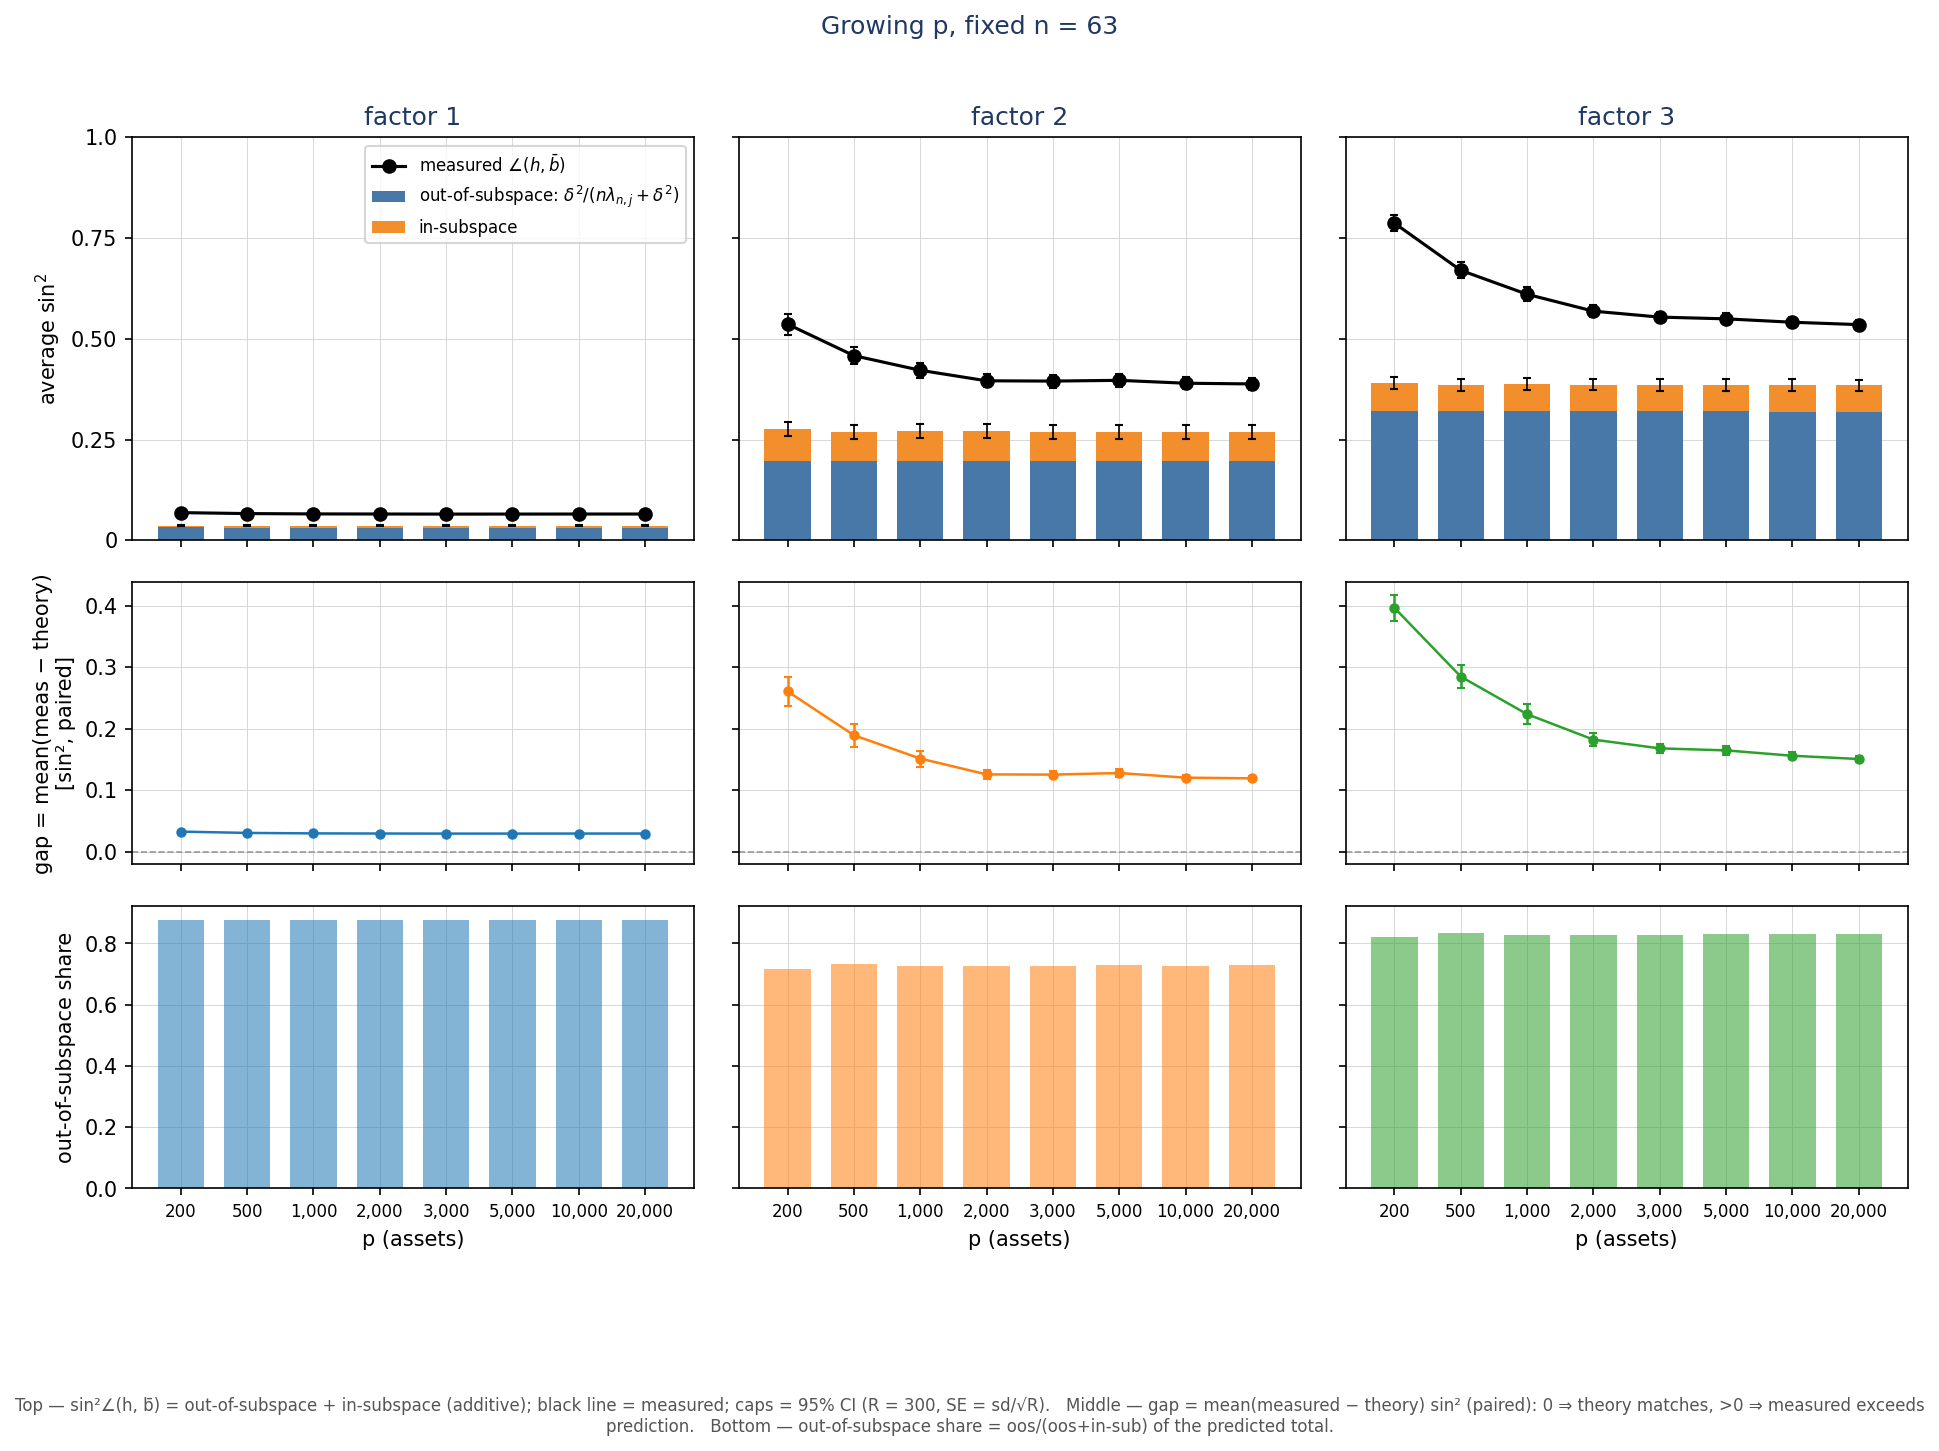

In [ ]:
design_p = DesignSpec(
    n_values=[63],
    # p_values=[200, 500, 1000, 2000, 3000, 5000, 10000, 20000],
    p_values = [100, 500, 5000, 10000, 20000, 100000, 500000 ],  # for heavy-tailed returns, we need to go bigger on p to see the asymptotic regime
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
show(design_p, "growing_p")


## Fixed $p = 3000$, growing $n$

Both error pieces shrink as $n$ grows ($F^\top F/n \to \Sigma_F$).

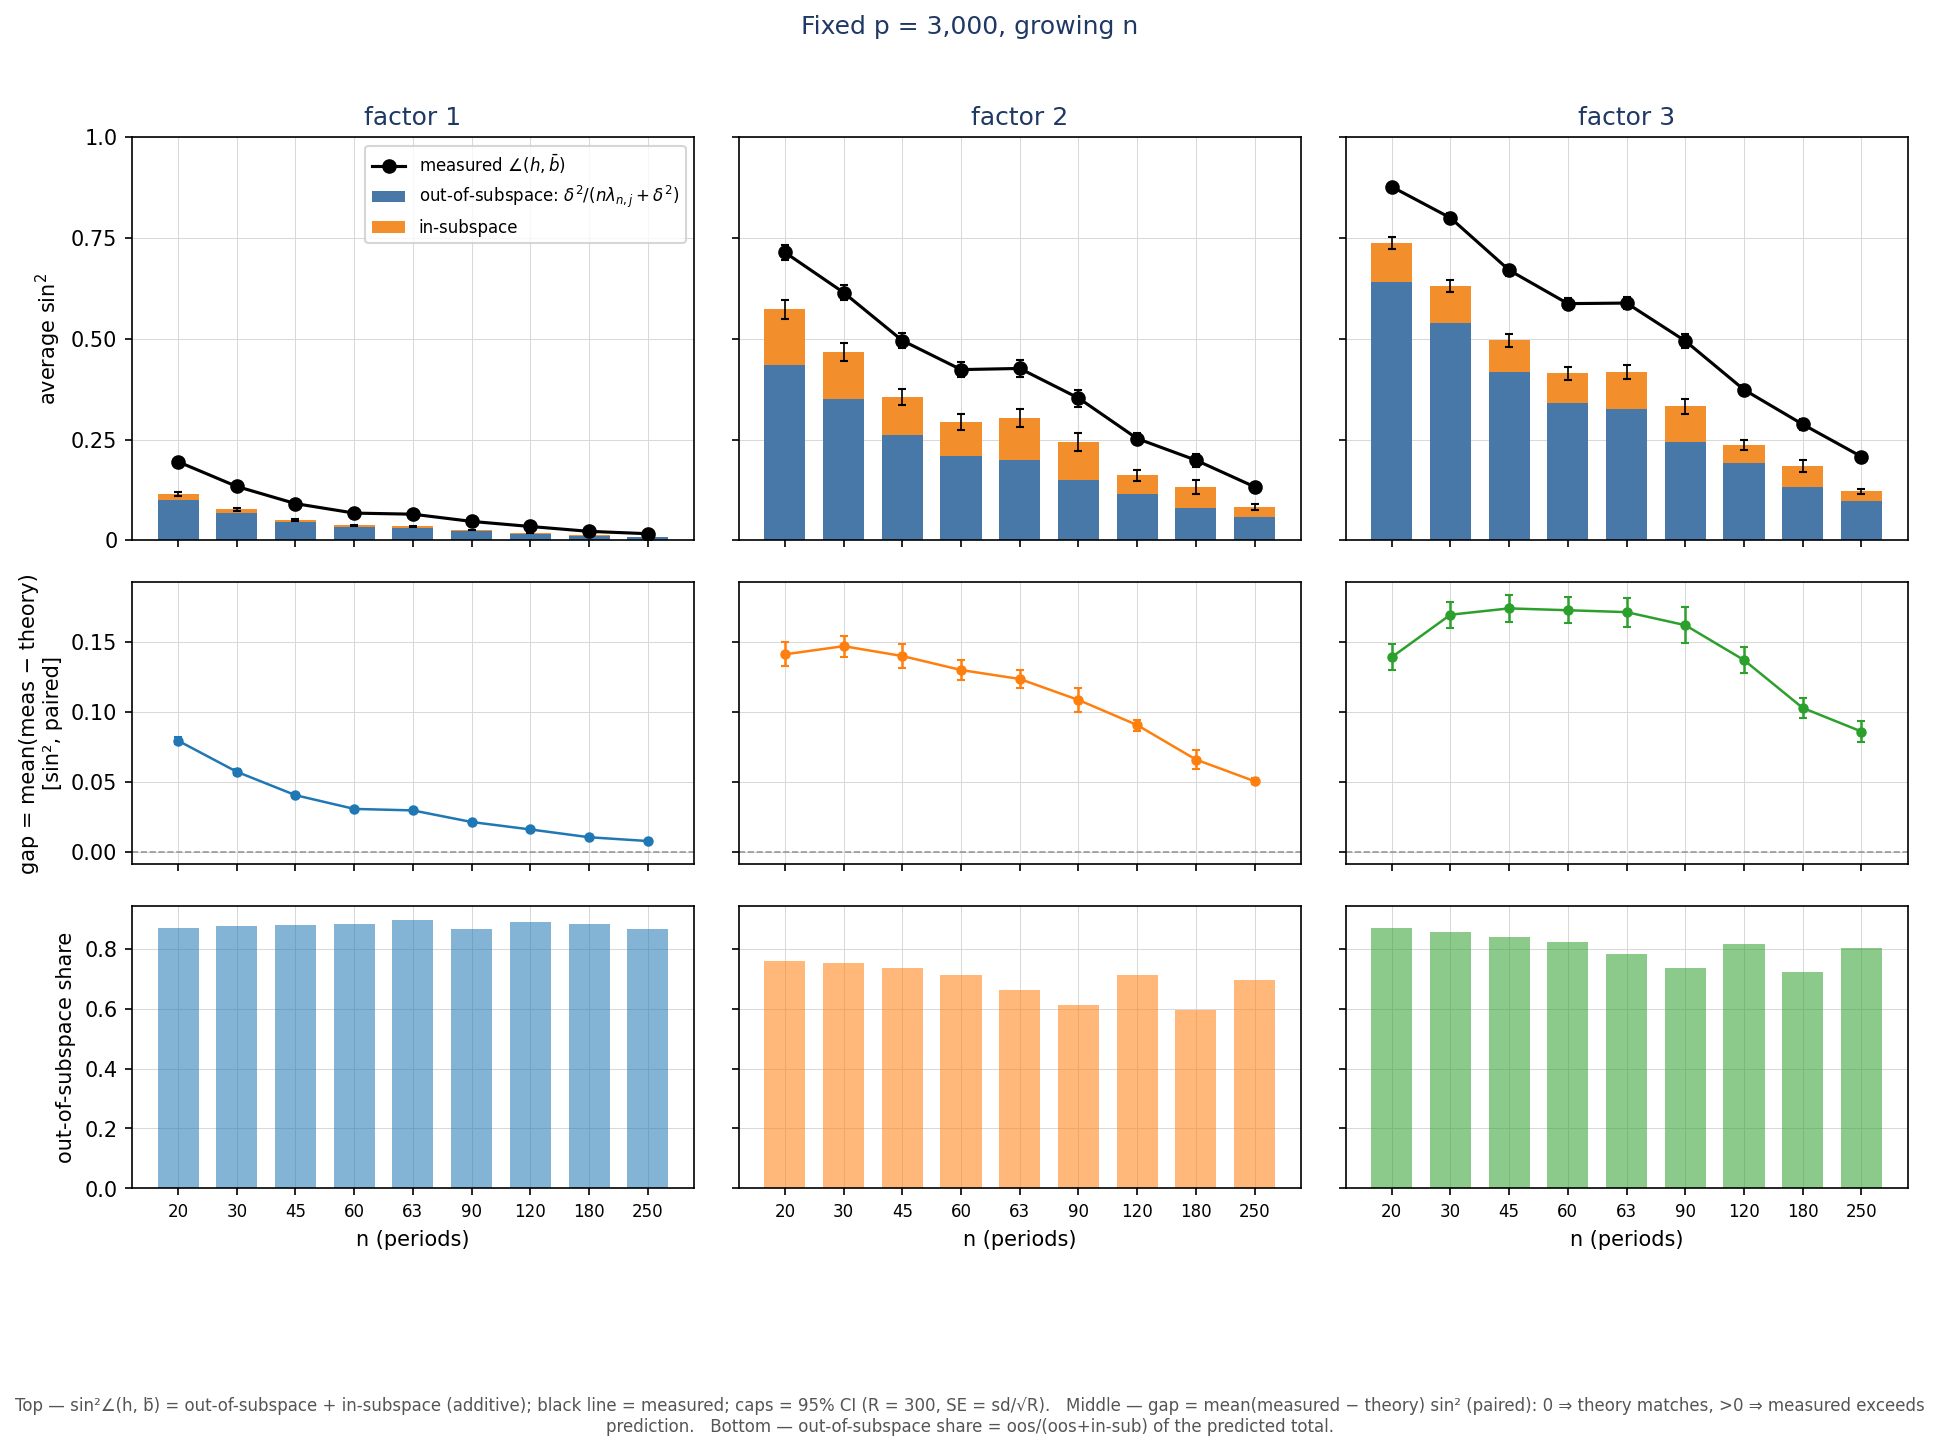

In [3]:
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250],
    p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", **HEAVY_TAIL,
)
show(design_n, "growing_n")

## Fixed $p = 3000$, growing $n$ — `nest_time=True`

Nesting the time axis (each $n$ is a prefix of one $n_{\max}$ draw) gives a smoother curve.

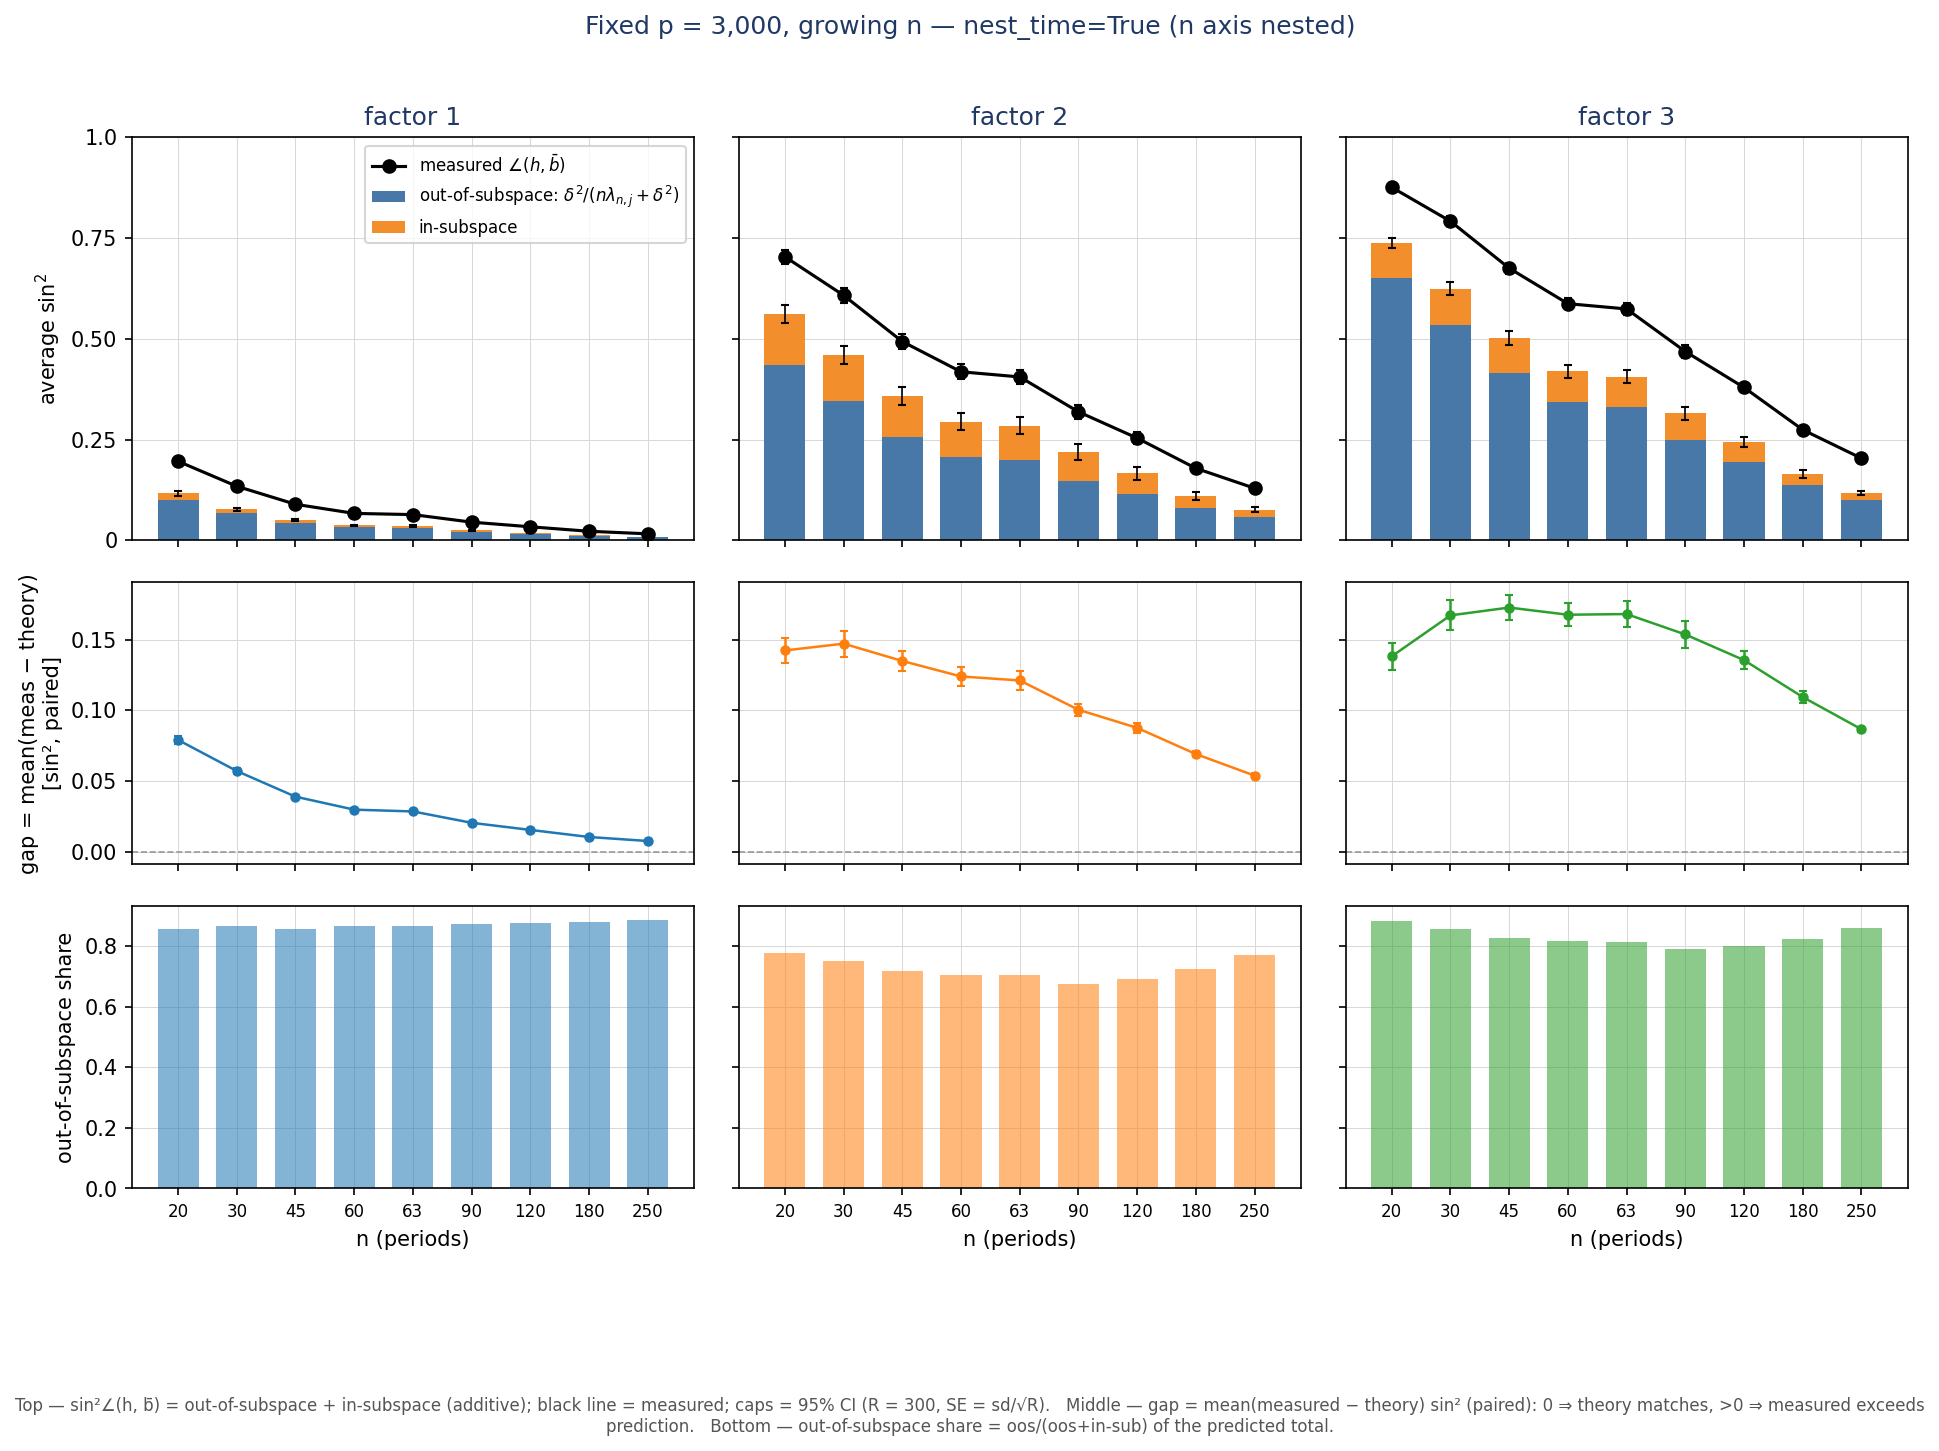

In [4]:
design_nt = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250],
    p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
show(design_nt, "nest_time",
     suptitle="Fixed p = 3000, growing n — nest_time=True (n axis nested)")